# 第二回: 入試問題を解く (その2) 記述する・解答する

```{hint}
* 次の例題の出典は？
```

### 2.11.1 操作環境の準備

In [ ]:
using Pkg
Pkg.activate("../..")
Pkg.instantiate()
using GeoGebra
ENV["GGB_DIRECT_TRANSPORT"] = true

In [ ]:
inject_applet()

In [ ]:
versioninfo()

In [ ]:
@ggb :api getVersion()

### 2.11.2 作図    

In [ ]:
@ggb :const :new

In [ ]:
@ggb O = (0, 0)

In [ ]:
@ggb :api getValueString(:O)

In [ ]:
@ggb Circle(:O, 6)

In [ ]:
@ggb M = Point(:c)

In [ ]:
@ggb r_1 = 12
@ggb r_2 = 9

In [ ]:
@ggb Circle(:M, :r_1)
@ggb Circle(:M, :r_2)

In [ ]:
@ggb {Tangent(:M, :c)}

In [ ]:
@ggb l1(1)

In [ ]:
@ggb {Intersect(d, f)}
@ggb {Intersect(e, f)}

In [ ]:
@ggb "P = If(x(l2(1)) < x(M), l2(1), l2(2))"

In [ ]:
@ggb "Q = If(x(l3(1)) > x(M), l3(1), l3(2))"

In [ ]:
@ggb {Tangent(c, P)}

In [ ]:
@ggb {Tangent(c, Q)}

In [ ]:
@ggb "If(Distance(M, l4(1)) > 0, l4(1), l4(2))"

In [ ]:
@ggb "If(Distance(M, l5(1)) > 0, l5(1), l5(2))"

In [ ]:
@ggb R = Intersect(:g, :h)

In [ ]:
@ggb {Intersect(c, g)}

In [ ]:
@ggb {Intersect(c, h)}

In [ ]:
@ggb K = l6(1)

In [ ]:
@ggb L = l7(1)

### 2.11.3 作図手順

In [ ]:
@ggb :const

```{seealso}
* [令和８年度試験 | 独立行政法人 大学入試センター](https://www.dnc.ac.jp/kyotsu/shiken_jouhou/r8/)
* [【日経】共通テスト2026　問題と正解（旧センター試験） - 日本経済新聞](https://www.nikkei.com/telling/DGXZTS00018940U5A221C2000000/)
```

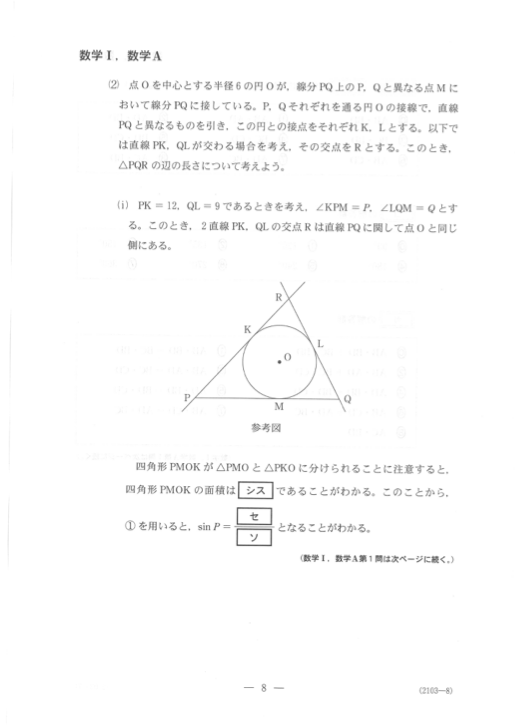

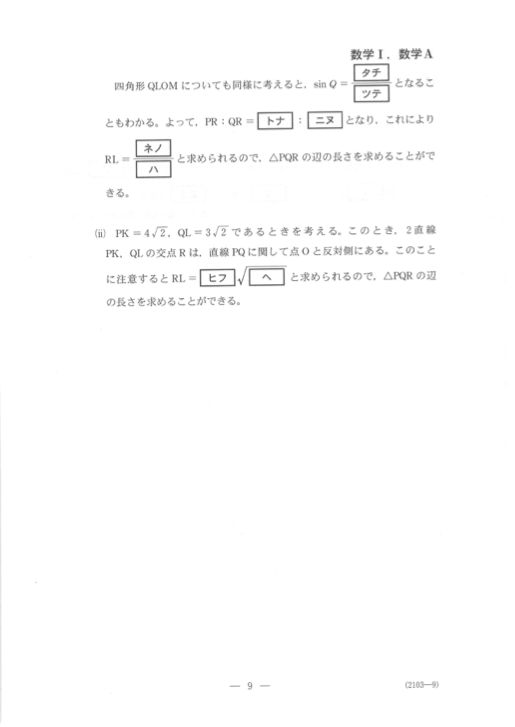

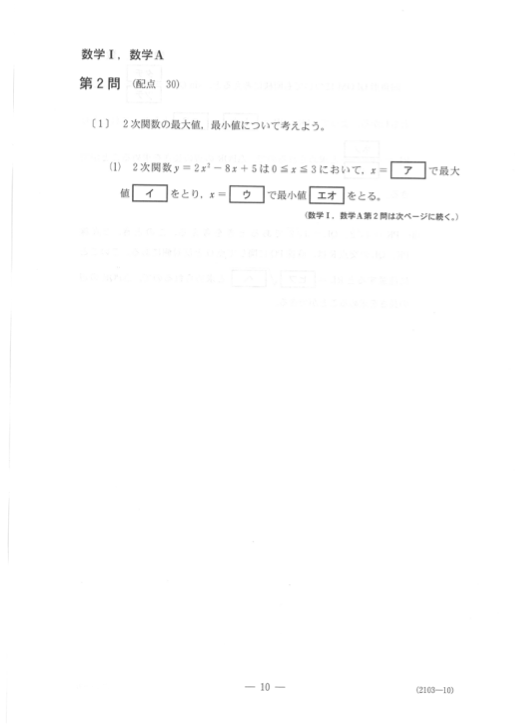

### 2.11.4 関係の記述 (その1)

```{tip}
PK=12、QL=9であるときを考え、(中略)。
このとき、2直線PK、QLの交点Rは直線PQに関して点Oと同じ側にある
```

In [ ]:
using PythonCall

In [ ]:
o = parse.(Float64, pyconvert(Vector{String}, refresh!(@ggb(:const("O"))).data["element"][0]["coords"][0].values()))[1:2]

In [ ]:
m = [(@ggb :api getXcoord(:M)), (@ggb :api getYcoord(:M))]

In [ ]:
r = [(@ggb :api getXcoord(:R)), (@ggb :api getYcoord(:R))]

In [ ]:
(r-m)' * (o-m)

In [ ]:
using LinearAlgebra

In [ ]:
((r-m) ⋅ (o-m)) > 0

### 2.11.4 関係の記述 (その2)

```{tip}
PK=$4 \sqrt{2}$、QL=$3 \sqrt(2)$であるときを考える。
このとき、2直線PK、QLの交点Rは直線PQに関して点Oと反対側にある。
```

In [ ]:
@ggb r_1 = 4*sqrt(2)
@ggb r_2 = 3*sqrt(2)

In [ ]:
r = [(@ggb :api getXcoord(:R)), (@ggb :api getYcoord(:R))]

In [ ]:
(r-m) ⋅ (o-m) > 0

## 2.11.5 作図手順の保存

In [28]:
using PythonCall

In [29]:
ggb = pyimport("ggblab")
ggb.file = pyimport("ggblab.file").ggb_file()
ggb.parser = pyimport("ggblab.parser").ggb_parser()
ggb.schema = pyimport("ggblab.schema").ggb_schema()

Python: <ggblab.schema.ggb_schema object at 0x147b5c520>

Info: PersistentCounter disabled when called from Julia/PythonCall


In [30]:
ggbex = pyimport("ggblab_extra")
ConstructionIO = ggbex.ConstructionIO
ConstructionTreeParser = ggbex.ConstructionTreeParser

Python: <class 'ggblab_extra.construction_parser.ConstructionTreeParser'>

In [31]:
pl = pyimport("polars")
ggbex_sympy = pyimport("ggblab_extra.sympy")

Python: <module 'ggblab_extra.sympy' from '/Users/manabu/work/ggblab/textbook-2026/.CondaPkg/.pixi/envs/default/lib/python3.14/site-packages/ggblab_extra/sympy/__init__.py'>

In [32]:
df = @await ConstructionIO.initialize_dataframe(ggb, use_applet=true)

┌ Warning: comm_direct: async requeue failed
│   err = InterruptException:
│   key = "30ac8e53-b2d6-4760-9c6e-afea16e3c4a5"
└ @ GeoGebra ~/.julia/packages/GeoGebra/nWAvL/src/comm_direct.jl:821


LoadError: Python: Julia: TaskFailedException
Stacktrace:
  [1] [0m[1m#wait#582[22m
[90m    @[39m [90m./[39m[90m[4mtask.jl:363[24m[39m[90m [inlined][39m
  [2] [0m[1mwait[22m
[90m    @[39m [90m./[39m[90m[4mtask.jl:360[24m[39m[90m [inlined][39m
  [3] [0m[1msend_and_wait_for_id[22m[0m[1m([22m[90mkey[39m::[0mString, [90mpayload[39m::[0mDict[90m{String, Any}[39m; [90mtimeout[39m::[0mFloat64[0m[1m)[22m
[90m    @[39m [32mGeoGebra[39m [90m~/.julia/packages/GeoGebra/nWAvL/src/[39m[90m[4mcomm_direct.jl:567[24m[39m
  [4] [0m[1msend_and_wait_for_id[22m
[90m    @[39m [90m~/.julia/packages/GeoGebra/nWAvL/src/[39m[90m[4mcomm_direct.jl:477[24m[39m[90m [inlined][39m
  [5] [0m[1m_auto_request_handler[22m[0m[1m([22m[90mpayload[39m::[0mDict[90m{String, Any}[39m[0m[1m)[22m
[90m    @[39m [32mGeoGebra[39m [90m~/.julia/packages/GeoGebra/nWAvL/src/[39m[90m[4mGeoGebra.jl:91[24m[39m
  [6] [0m[1mrequest[22m[0m[1m([2

Info: PersistentCounter disabled when called from Julia/PythonCall


In [ ]:
print(ConstructionIO.commands_for_magic(df, use_name_equals=true))

In [ ]:
df.write_parquet("02_11.parquet")

In [33]:
df2 = pl.read_parquet("01_21.parquet")

Sequence,Name,Type,Command,Value,Caption,Layer,ShowObject,ShowLabel,Auxiliary
u32,str,str,str,str,str,u32,bool,bool,bool
1,"""O""","""point""","""(0, 0)""","""O = (0, 0)""",null,0,false,false,false
2,"""c""","""circle""","""Circle(O, 6)""","""c: x² + y² = 36""",null,0,true,true,false
3,"""M""","""point""","""Point(c)""","""M = (-0.0261703326075, -5.9999…",null,0,true,true,false
4,"""r_1""","""numeric""","""12""","""r_1 = 12""",null,0,false,false,false
5,"""r_2""","""numeric""","""9""","""r_2 = 9""",null,0,false,false,false
6,"""d""","""circle""","""Circle(M, r_1)""","""d: (x + 0.0261703326075)² + (y…",null,0,false,true,false
7,"""e""","""circle""","""Circle(M, r_2)""","""e: (x + 0.0261703326075)² + (y…",null,0,false,true,false
8,"""l1""","""list""","""{Tangent(M, c)}""","""l1 = {-0.0261703326075x - 5.99…",null,0,false,true,false
9,"""f""","""line""","""l1(1)""","""f: l1(1)""",null,0,true,true,false


## 2.11.5 作図手順の自己採点

In [ ]:
p = ConstructionTreeParser(df)

In [ ]:
g = p.parse()

In [ ]:
nx = pyimport("networkx")

In [ ]:
nx.write_network_text(g)

In [ ]:
GraphSimilarity = pyimport("ggblab_extra.graph_similarity")

In [ ]:
GraphSimilarity.hungarian_similarity(g, g)[0]

```{attention} この授業での作図手順
* GeoGebraのinject (mount)
* レファレンスとなる作図手順の読み込みと表示
* 作図手順の再現と自己採点
* 対話的な操作
* 解析
    - 有向グラフ
    - 数式
        - 分かち書き
```